In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

import math 

In [2]:
h = 6.626e-34            # J·s
kB = 1.380649e-23         # J K-1 
c = 3.00e8                  # m s-1 

In [3]:
def blackbody_radiation(T, v):
    return ((8 * math.pi * h)/c**3) * (v**3/(math.exp((h * v) / (kB * T))-1))


def plot_blackbody_radiation(*temperatures, sample_size=100):

    velocities = np.linspace(0.01, 16, num=sample_size) * 1e14
    vectorized_blackbody_radiation = np.vectorize(blackbody_radiation)

    df = pd.DataFrame(index=velocities)
    energy_densities = {}

    for t in temperatures:  
        radiation = vectorized_blackbody_radiation(t, velocities)
        df[t] = radiation

        energy_density = metrics.auc(velocities, radiation)
        energy_densities[t] = energy_density

    auc = pd.Series(energy_densities,
    name="AUC"
)    
    df.plot(figsize=(8, 6))
    
    plt.xlabel(r'$\nu / 10^{14}\ \mathrm{s^{-1}}$')
    plt.ylabel('Intensity of blackbody radiation')
    plt.title('Blackbody Radiation')
    plt.legend(title='Temperature (K)')
    plt.show()

    return df, auc 

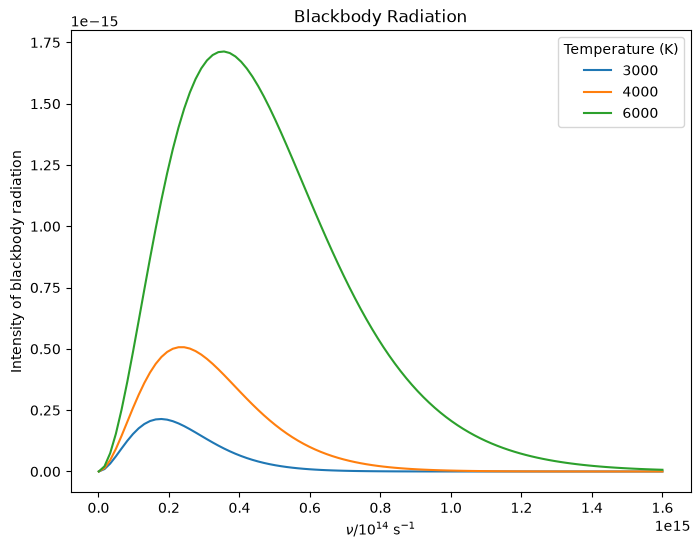

In [4]:
df, auc = plot_blackbody_radiation(3000, 4000, 6000, sample_size=100)